# 11 — E7: Cross-Language Circuit Sharing

**Hypothesis H6:** Semantically equivalent concepts share >10% of concept-only neurons
across languages within each model.

For each abstract concept (e.g., "Iteration"), pools concept-only neurons from
Python and Rust members, computes their intersection.

In [1]:
# Cell 1 – Configuration
import subprocess, sys, os
import ast as ast_mod
for pkg in ["numpy", "pandas", "matplotlib", "seaborn"]:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

MODEL_CONFIGS = {
    "QW": {"id": "Qwen/Qwen2.5-Coder-7B",                "n_layers": 28, "mlp_dim": 3584},
    "DS": {"id": "deepseek-ai/deepseek-coder-6.7b-base",  "n_layers": 32, "mlp_dim": 4096},
}
MODELS = ["QW"]  # add "DS" when available
EPSILON = "0.5"
CONSISTENCY = "0.8"
N_LAYERS = max(c["n_layers"] for c in MODEL_CONFIGS.values())
N_PERMUTATIONS = 1000
SEED = 42

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import shutil
    mp = "/content/drive"
    subprocess.run(["fusermount", "-uz", mp], capture_output=True)
    if os.path.isdir(mp):
        shutil.rmtree(mp, ignore_errors=True)
    drive.mount(mp)
    DATA_DIR = "/content/drive/MyDrive/DATA/New-Atlas"
else:
    DATA_DIR = "/Users/piotrwilam/Data/New-Atlas"



print(f"Models: {MODELS}, eps={EPSILON}, cons={CONSISTENCY}")

Models: ['QW'], eps=0.5, cons=0.8


In [2]:
# Cell 2 – Cross-language equivalence map

EQUIVALENCE_MAP = {
    "Iteration":     {"P": ["ast__For", "ast__While"],
                      "R": ["rust__For", "rust__Loop", "rust__While"]},
    "Binding":       {"P": ["ast__Assign"],
                      "R": ["rust__Let", "rust__LetMut"]},
    "Branching":     {"P": ["ast__If", "ast__IfExp"],
                      "R": ["rust__If", "rust__Match"]},
    "Function def":  {"P": ["ast__FunctionDef", "ast__Lambda"],
                      "R": ["rust__Fn", "rust__Closure"]},
    "Error handling":{"P": ["ast__Try", "ast__Raise"],
                      "R": ["rust__QuestionMark"]},
    "Module import": {"P": ["ast__Import", "ast__ImportFrom"],
                      "R": ["rust__Use", "rust__Mod"]},
    "Loop control":  {"P": ["ast__Break", "ast__Continue"],
                      "R": ["rust__Break", "rust__Continue"]},
    "Return":        {"P": ["ast__Return"],
                      "R": ["rust__Return"]},
    "Type def":      {"P": ["ast__ClassDef"],
                      "R": ["rust__Struct", "rust__Enum"]},
}

print(f"Equivalence classes: {len(EQUIVALENCE_MAP)}")

Equivalence classes: 9


In [3]:
# Cell 3 – Load neuron lists


def load_neuron_list(data_dir, prefix, eps, cons, obj_type="both"):
    """Load neuron list CSV, concatenating part1+part2 split files."""
    # Try split files first (new format)
    p1 = os.path.join(data_dir, f"{prefix}4_neuron_list_eps{eps}_cons{cons}_layers_part1_{obj_type}.csv")
    p2 = os.path.join(data_dir, f"{prefix}4_neuron_list_eps{eps}_cons{cons}_layers_part2_{obj_type}.csv")
    if os.path.exists(p1) and os.path.exists(p2):
        return pd.concat([pd.read_csv(p1), pd.read_csv(p2)], ignore_index=True)
    # Fallback: try all_layers (old format)
    old = os.path.join(data_dir, f"{prefix}4_neuron_list_eps{eps}_cons{cons}_all_layers_{obj_type}.csv")
    if os.path.exists(old):
        return pd.read_csv(old)
    return None

data = {}  # (lang, model) -> DataFrame

neuron_data = {}  # (lang, model) -> DataFrame

for model in MODELS:
    for lang in ["P", "R"]:
        prefix = f"{lang}_{model}_"
        df = load_neuron_list(DATA_DIR, prefix, EPSILON, CONSISTENCY)
        if df is None:
            print(f"  WARNING: missing {lang}_{model}")
            continue

        neuron_data[(lang, model)] = df
        print(f"  {lang}_{model}: {len(df)} rows, {df['object'].nunique()} objects")

print(f"Loaded: {len(neuron_data)} datasets")

  P_QW: 1624 rows, 58 objects
  R_QW: 1596 rows, 57 objects
Loaded: 2 datasets


In [4]:
# Cell 4 – Compute cross-language sharing

def get_concept_only_set(df, obj_name, layer):
    row = df[(df["object"] == obj_name) & (df["layer"] == layer)]
    if len(row) == 0:
        return set()
    return set(ast_mod.literal_eval(row.iloc[0]["concept_only"]))


def pool_neurons(df, members, layer):
    """Union of concept-only neurons across group members."""
    pool = set()
    for m in members:
        pool |= get_concept_only_set(df, m, layer)
    return pool


rng = np.random.default_rng(SEED)
results = []

for model in MODELS:
    py_df = neuron_data.get(("P", model))
    rs_df = neuron_data.get(("R", model))
    if py_df is None or rs_df is None:
        print(f"  Skipping {model}: missing P or R data")
        continue

    py_objects = sorted(py_df["object"].unique())
    rs_objects = sorted(rs_df["object"].unique())

    for eq_name, members in EQUIVALENCE_MAP.items():
        py_members = [m for m in members["P"] if m in py_objects]
        rs_members = [m for m in members["R"] if m in rs_objects]

        if not py_members or not rs_members:
            continue

        for layer in range(N_LAYERS):
            py_pool = pool_neurons(py_df, py_members, layer)
            rs_pool = pool_neurons(rs_df, rs_members, layer)

            shared = py_pool & rs_pool
            min_pool = min(len(py_pool), len(rs_pool))
            sharing_frac = len(shared) / min_pool if min_pool > 0 else 0.0

            # Permutation null
            null_sharing = []
            p_k, r_k = len(py_members), len(rs_members)
            for _ in range(N_PERMUTATIONS):
                rand_py = rng.choice(py_objects, size=p_k, replace=False).tolist()
                rand_rs = rng.choice(rs_objects, size=r_k, replace=False).tolist()
                null_py = pool_neurons(py_df, rand_py, layer)
                null_rs = pool_neurons(rs_df, rand_rs, layer)
                null_shared = null_py & null_rs
                null_min = min(len(null_py), len(null_rs))
                null_sharing.append(len(null_shared) / null_min if null_min > 0 else 0.0)

            p_value = np.mean([ns >= sharing_frac for ns in null_sharing])

            results.append({
                "model": model, "equivalence_class": eq_name,
                "layer": layer,
                "py_pool_size": len(py_pool),
                "rs_pool_size": len(rs_pool),
                "shared_count": len(shared),
                "sharing_fraction": sharing_frac,
                "p_value": p_value,
            })

    print(f"  {model}: done")

df_results = pd.DataFrame(results)
print(f"\nTotal: {len(df_results)} rows")

  QW: done

Total: 224 rows


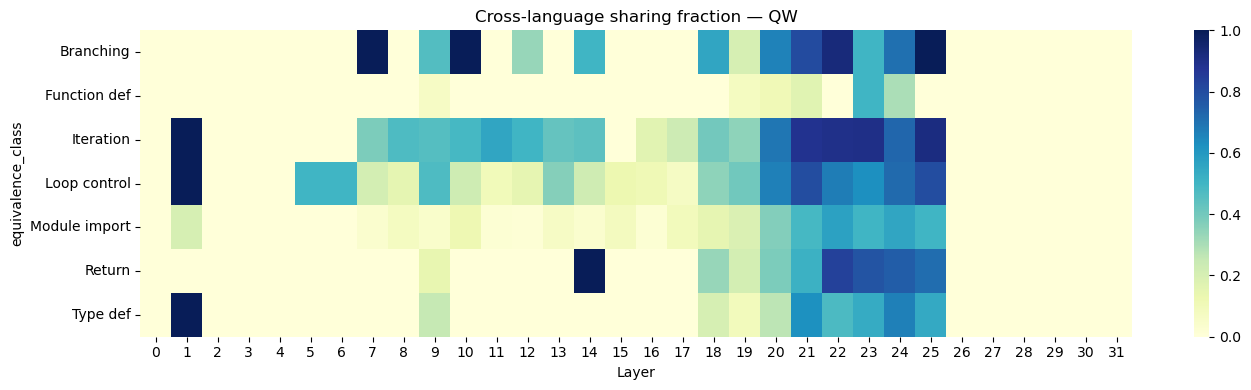

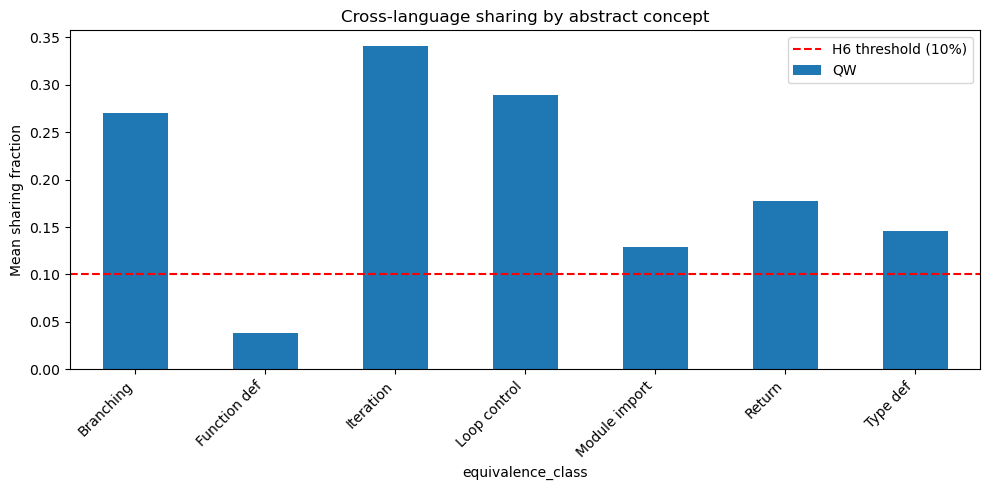


H6 test: 6/7 equivalence classes have sharing > 10%


In [5]:
# Cell 5 – Sharing fraction heatmap

if len(df_results) > 0:
    for model in MODELS:
        sub = df_results[df_results["model"] == model]
        if len(sub) == 0:
            continue

        pivot = sub.pivot_table(index="equivalence_class", columns="layer",
                                values="sharing_fraction", aggfunc="mean")

        fig, ax = plt.subplots(figsize=(14, max(4, len(pivot)*0.5)))
        sns.heatmap(pivot, cmap="YlGnBu", vmin=0, ax=ax)
        ax.set_title(f"Cross-language sharing fraction — {model}")
        ax.set_xlabel("Layer")
        plt.tight_layout()
        plt.savefig(os.path.join(DATA_DIR, f"7_E7_sharing_heatmap_{model}.png"), dpi=150)
        plt.show()

    # Bar chart: mean sharing across layers
    fig, ax = plt.subplots(figsize=(10, 5))
    mean_sharing = (df_results.groupby(["model", "equivalence_class"])["sharing_fraction"]
                    .mean().reset_index())
    if len(mean_sharing) > 0:
        mean_sharing.pivot(index="equivalence_class", columns="model", values="sharing_fraction").plot(
            kind="bar", ax=ax)
        ax.axhline(y=0.1, color="red", linestyle="--", label="H6 threshold (10%)")
        ax.set_ylabel("Mean sharing fraction")
        ax.set_title("Cross-language sharing by abstract concept")
        ax.legend()
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.savefig(os.path.join(DATA_DIR, "7_E7_sharing_bar.png"), dpi=150)
        plt.show()

    # H6 test
    above_10 = (mean_sharing["sharing_fraction"] > 0.10).sum()
    total = len(mean_sharing)
    print(f"\nH6 test: {above_10}/{total} equivalence classes have sharing > 10%")
else:
    print("No results.")

In [6]:
# Cell 6 – Save

if len(df_results) > 0:
    out_path = os.path.join(DATA_DIR, "7_E7_cross_language_results.csv")
    df_results.to_csv(out_path, index=False)
    print(f"Saved: {out_path}")

print("\n11 complete.")

Saved: /Users/piotrwilam/Data/New-Atlas/7_E7_cross_language_results.csv

11 complete.
